# Logistic Regression


<span style="color: green;">**Logistic Regression is a supervised machine learning algorithm used for classification tasks — especially binary classification (yes/no, 0/1, true/false).**</span>
**It predicts the probability that a given input belongs to a particular class.**



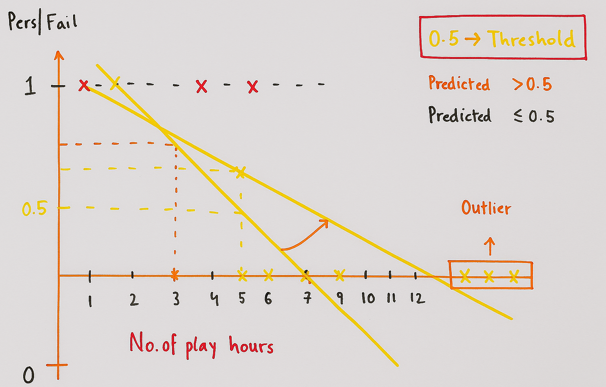 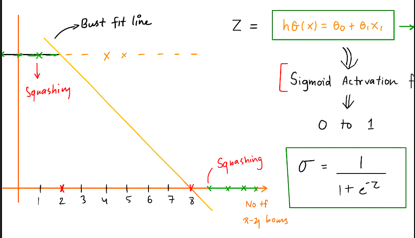

## Loss Function (Binary Cross Entropy / Log Loss):

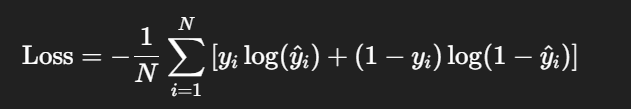

- Penalizes wrong predictions (especially confident wrong ones)

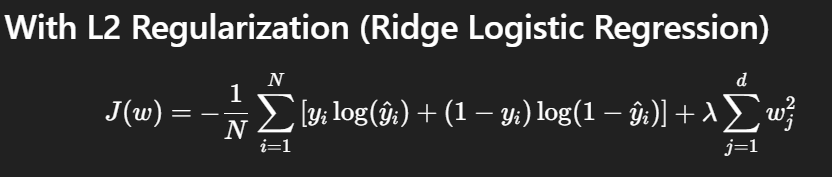

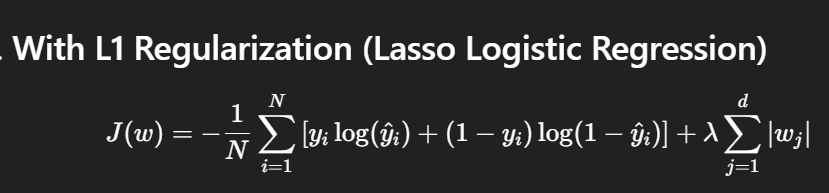

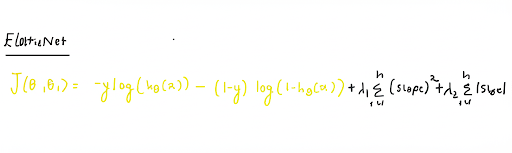

<span style="color: red;">**Notes:**</span>
- The bias/intercept term is usually not regularized.
- In Scikit-learn:
    - penalty='l1' or 'l2' or 'elasticnet'
    - C = 1 / λ (inverse of regularization strength)
    - l1_ratio controls the balance between L1 and L2 in Elastic Net.

## Assumptions of Logistic Regression

|    | Assumption                                       | Explanation                                                                                                                                       |
| --: | ------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1 | **Binary or Multiclass Dependent Variable**      | The outcome should be binary (0/1) or multinomial (for multinomial logistic regression).                                                          |
| 2️ | **Independence of Observations**                 | Each observation (data point) should be independent of others—no duplicate or related samples.                                                    |
| 3️ | **Linearity of Log-Odds (Not Outcome)**          | Logistic regression assumes a **linear relationship between input features and the log-odds** of the dependent variable, not the outcome itself.  |
| 4️ | **No or Little Multicollinearity**               | Independent variables should not be highly correlated with each other. Use VIF (Variance Inflation Factor) to check.                              |
| 5️ | **Large Sample Size**                            | A larger dataset helps the model estimate probabilities more accurately and reduces overfitting.                                                  |
| 6️ | **No Extreme Outliers**                          | Outliers in independent variables can distort the relationship between predictors and log-odds.                                                   |
| 7️ | **Features Are Meaningful and Additive**         | Each feature contributes additively (linearly) to the log-odds of the outcome.                                                                    |
| 8️ | **Independent Variables are Linearly Separable** | For binary classification, classes should be **somewhat separable** by a linear boundary (not a strict requirement, but it improves performance). |


## Logistic Regression vs. Linear Regression

| Feature                  | **Linear Regression**                            | **Logistic Regression**                                                            |
| ------------------------ | ------------------------------------------------ | ---------------------------------------------------------------------------------- |
| **Purpose**              | Predicts **continuous** values                   | Predicts **categorical** outcomes (e.g., 0 or 1)                                   |
| **Output Range**         | $(-\infty, +\infty)$                             | $(0, 1)$ (interpreted as probability)                                              |
| **Equation**             | $y = \beta_0 + \beta_1x_1 + \cdots + \beta_nx_n$ | $p = \frac{1}{1 + e^{-z}}$, where $z = \beta_0 + \beta_1x_1 + \cdots + \beta_nx_n$ |
| **Activation Function**  | None                                             | Sigmoid                                                                            |
| **Cost Function**        | Mean Squared Error (MSE)                         | Log Loss (Cross-Entropy)                                                           |
| **Relationship Assumed** | Linear between input and output                  | Linear between input and **log-odds** of output                                    |
| **Prediction Type**      | Regression                                       | Classification (binary or multi-class)                                             |
| **Decision Threshold**   | Not required                                     | Typically uses threshold (e.g., 0.5)                                               |
| **Graph Shape**          | Straight line                                    | S-curve (sigmoid)                                                                  |
| **Common Use Cases**     | House prices, temperature prediction             | Spam detection, disease prediction, fraud detection                                |


## Confusion Matrix (Binary Classification)

|                          | **Actual: Positive (1)** | **Actual: Negative (0)** |
| ------------------------ | --------------------------- | --------------------------- |
| **Predicted: Positive (1)** |  True Positive (TP)        |  False Positive (FN)       |
| **Predicted: Negative (0)** |  False Negative (FP)       |  True Negative (TN)        |


**1. Accuracy**

**Measures overall correctness of the model.**

   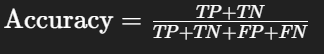 

**Limitations:**
- Misleading in imbalanced datasets
- Ignores the cost of false positives and false negatives.

**2. Precision**

**Out of all positive predictions, how many were actually correct?**

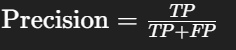

**Limitations:**
- Sensitive to False Positives
- Ignores False Negatives

**3. Recall**

**Out of all actual positives, how many did the model catch?**

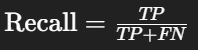

**Limitations:**
- Sensitive to False Negatives:
- Ignores Precision

**4. F-beta Score**

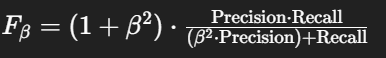
- F1 Score: Harmonic mean of precision and recall (β = 1)
- F2 Score: Weighs recall higher (β = 2)
- F0.5 Score: Weighs precision higher (β = 0.5)

**Limitations:**
- Ignores true negatives
- Requires choosing β value based on task preference 

## When to Use What:

| Metric        | Best When...                                          |
| ------------- | ----------------------------------------------------- |
| **Accuracy**  | Dataset is balanced and all errors are equally costly |
| **Precision** | False positives are costly (e.g., spam detection)     |
| **Recall**    | False negatives are costly (e.g., cancer detection)   |
| **F-beta**    | Trade-off between Precision and Recall is critical    |


---

---

# Cross Validation

**Cross Validation is a statistical technique used to assess how well a model generalizes to an independent dataset. It's especially useful for avoiding overfitting and selecting the best model or hyperparameters.**

## Types of Cross Validation

**1.Leave-One-Out CV (LOOCV)**
- Each data point is used once as validation; the rest are used for training.
- Best for very small datasets, but computationally expensive.
- Training acc high but testing low
  
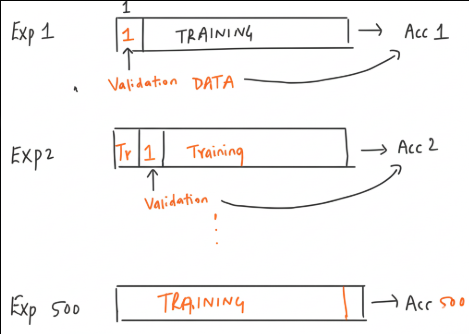

<span style="color: red;">**2.K-Fold Cross Validation**</span>
- The dataset is split into k equal parts (folds).
- The model is trained and validated k times.
- In each round:
    - k−1 folds are used to train the model.
    - 1 fold (the remaining one) is used to validate.
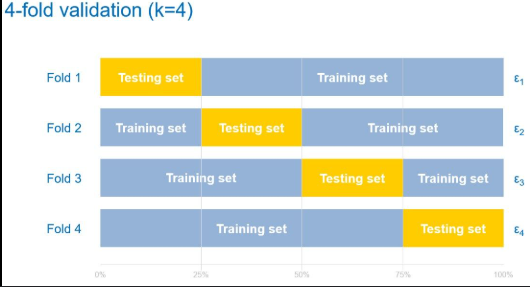

**3. Stratified K-Fold**
- Used for Imbalanced Dataset
- Ensures each fold has the same class distribution as the overall dataset.
- Important for imbalanced classification problems.
- Number of 0 and 1 in vaildation always same  

**4. Repeated K-Fold**
- K-Fold CV is repeated multiple times with different splits.
- Increases reliability of performance estimate.

**5. Time Series (Rolling) CV**
- For time-dependent data (e.g., stock prices, driver behavior over time).
- Training set grows, test set moves forward in time.
- Example:
    - Train: t1–t10 | Test: t11
    - Train: t1–t11 | Test: t12
    - Train: t1–t12 | Test: t13 ...


# Hyperparameter Tuning

**Hyperparameter tuning is the process of optimizing the parameters that are not learned from data during training, but set before training the model.**

# Hyperparameter Tuning Methods:

**1. Manual Search**
- Change parameters by hand.
- Not scalable but useful for intuition.

**2.** <span style="color: red;">**Grid Search (GridSearchCV)**</span>
- Try all combinations of hyperparameter values.
- Works well for small search spaces.

In [36]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'C': [0.1, 1, 10],
#     'penalty': ['l1', 'l2'],
#     'solver': ['liblinear']
# }

# grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
# grid.fit(X_train, y_train)

# print("Best Parameters:", grid.best_params_)
# print("Best Score:", grid.best_score_)


**3.** <span style="color: red;">**Random Search (RandomizedSearchCV)**</span> 
- Randomly samples hyperparameter combinations.
- Faster than grid search.

In [38]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform

# param_dist = {
#     'C': uniform(0.01, 10),
#     'penalty': ['l1', 'l2'],
#     'solver': ['liblinear']
# }

# random_search = RandomizedSearchCV(LogisticRegression(), param_distributions=param_dist, n_iter=10, cv=5)
# random_search.fit(X_train, y_train)

# print("Best Parameters:", random_search.best_params_)


| Feature               | GridSearchCV                   | RandomizedSearchCV                                   |
| --------------------- | ------------------------------ | ---------------------------------------------------- |
| Search type           | Exhaustive (all combinations)  | Random sampling                                      |
| Speed                 | Slow (combinatorial explosion) | Faster (limited evaluations)                         |
| Best result guarantee |  Yes                          |  Not guaranteed                                     |
| Custom distributions  |  Fixed list only              |  Supports distributions (e.g., uniform, loguniform) |
| When to use           | Small search spaces            | Large or continuous search spaces                    |


**4. Bayesian Optimization (e.g., Optuna, Hyperopt, Scikit-Optimize)**
- Learns from previous iterations to try better hyperparameter combinations.
- Efficient for large and complex search spaces.

## Hyperparameters:

| Model               | Hyperparameters                                                          |
| ------------------- | ------------------------------------------------------------------------ |
| Logistic Regression | `C`, `penalty`, `max_iter`                                               |
| Decision Tree       | `max_depth`, `min_samples_split`, `criterion`                            |
| SVM                 | `C`, `kernel`, `gamma`                                                   |
| KNN                 | `n_neighbors`, `weights`, `metric`                                       |
| Neural Networks     | `learning rate`, `batch size`, `number of layers`, `optimizer`, `epochs` |


------

------